# **EDA: RAVDESS**

**Fuente:** https://zenodo.org/records/1188976

Este notebook realiza un Análisis Exploratorio de Datos (EDA) completo sobre el dataset RAVDESS, que contiene **7356 grabaciones** de 24 actores profesionales (12 hombres y 12 mujeres) expresando 8 emociones: neutral, tranquilo, feliz, triste, enfadado, con miedo, asco y sorpresa. Cada expresión se produce en dos niveles de intensidad emocional (normal y fuerte). Todas las grabaciones están disponibles en tres formatos de modalidad: solo audio, audio y vídeo y solo vídeo (sin sonido). Lo usamos para representar la clase `voice` con contexto emocional, lo que permite al modelo distinguir entre una voz en conversación normal y una voz en una situación de estrés o peligro.

## **1. Dependencias**

In [ ]:
# Instalar dependencias necesarias
%pip install librosa soundfile matplotlib seaborn pandas numpy plotly -q

In [2]:
import os
import re
import glob
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import librosa
import librosa.display
import plotly.express as px
import plotly.graph_objects as go
import requests
import zipfile
import os

from plotly.subplots import make_subplots
from IPython.display import Audio, display

In [3]:
# Estilo visual
sns.set_theme(style='darkgrid', palette='husl')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
print('Librerías cargadas.')

Librerías cargadas.


## **2. Carga del dataset**

### **Convención de nombres de archivo**
Cada archivo tiene un nombre con 7 identificadores numéricos separados por guiones:

```
02-01-06-01-02-01-12.wav
 │   │   │   │   │   │   └─ Actor (01-24; impares=masculino, pares=femenino)
 │   │   │   │   │   └───── Repetición (01=1ª, 02=2ª)
 │   │   │   │   └───────── Statement (01=Kids..., 02=Dogs...)
 │   │   │   └───────────── Intensidad (01=normal, 02=fuerte)
 │   │   └───────────────── Emoción (01-08)
 │   └───────────────────── Canal vocal (01=speech, 02=song)
 └───────────────────────── Modalidad (01=AV, 02=video-only, 03=audio-only)
```

In [4]:
# ──────────────────────────────────────────────────────────────
# CONFIGURAR AQUÍ la ruta a los archivos de audio RAVDESS
# Estructura esperada:
#   RAVDESS_DATA_PATH/
#     Actor_01/
#       03-01-01-01-01-01-01.wav
#       ...
#     Actor_02/
#       ...
# ──────────────────────────────────────────────────────────────

RAVDESS_DATA_PATH = './data/RAVDESS' # MODIFICAR ESTA RUTA

In [ ]:
# URLs de descarga de Zenodo para los audios de RAVDESS
SPEECH_ZIP_URL = "https://zenodo.org/record/1188976/files/Audio_Speech_Actors_01-24.zip?download=1"
SONG_ZIP_URL = "https://zenodo.org/record/1188976/files/Audio_Song_Actors_01-24.zip?download=1"

# Nombres de archivo para los zips descargados
SPEECH_ZIP_FILE = "Audio_Speech_Actors_01-24.zip"
SONG_ZIP_FILE = "Audio_Song_Actors_01-24.zip"

# Crear el directorio de datos si no existe
os.makedirs(RAVDESS_DATA_PATH, exist_ok=True)

def download_and_extract_zip(url, zip_filename, extract_to_path):
    print(f"Comprobando si {zip_filename.split('?')[0]} ya está descargado y extraído...")
    # Comprobar si existe algún directorio de actores dentro de RAVDESS_DATA_PATH
    if any(os.path.isdir(os.path.join(extract_to_path, d)) for d in os.listdir(extract_to_path) if d.startswith('Actor_')):
        print(f"Parece que los datos ya están en {extract_to_path}. Omitiendo la descarga de {zip_filename.split('?')[0]}.")
        return

    print(f"Descargando {zip_filename.split('?')[0]}...")
    try:
        r = requests.get(url, stream=True)
        r.raise_for_status() # Raise an exception for HTTP errors
        with open(zip_filename, "wb") as f:
            for chunk in r.iter_content(chunk_size=8192):
                f.write(chunk)
        print(f"Descarga de {zip_filename.split('?')[0]} completa. Extrayendo...")

        with zipfile.ZipFile(zip_filename, "r") as z:
            z.extractall(extract_to_path)
        os.remove(zip_filename)
        print(f"Extracción de {zip_filename.split('?')[0]} completa en {extract_to_path}.")
    except requests.exceptions.RequestException as e:
        print(f"Error al descargar {zip_filename.split('?')[0]}: {e}")
    except zipfile.BadZipFile:
        print(f"Error: El archivo {zip_filename.split('?')[0]} está corrupto o no es un archivo zip válido.")
    except Exception as e:
        print(f"Ocurrió un error inesperado: {e}")

# Descargar y extraer audios de voz (speech)
download_and_extract_zip(SPEECH_ZIP_URL, SPEECH_ZIP_FILE, RAVDESS_DATA_PATH)

# Descargar y extraer audios de canto (song)
download_and_extract_zip(SONG_ZIP_URL, SONG_ZIP_FILE, RAVDESS_DATA_PATH)

Comprobando si Audio_Speech_Actors_01-24.zip ya está descargado y extraído...
Parece que los datos ya están en ./data/RAVDESS. Omitiendo la descarga de Audio_Speech_Actors_01-24.zip.
Comprobando si Audio_Song_Actors_01-24.zip ya está descargado y extraído...
Parece que los datos ya están en ./data/RAVDESS. Omitiendo la descarga de Audio_Song_Actors_01-24.zip.


In [6]:
# Mapas de decodificación
MODALITY_MAP = {'01': 'AV', '02': 'Video-only', '03': 'Audio-only'}
CHANNEL_MAP = {'01': 'speech', '02': 'song'}
EMOTION_MAP = {'01': 'neutral', '02': 'calm', '03': 'happy',
               '04': 'sad', '05': 'angry', '06': 'fearful',
               '07': 'disgust', '08': 'surprised'}
INTENSITY_MAP = {'01': 'normal', '02': 'strong'}
STATEMENT_MAP = {'01': 'Kids are talking by the door',
                 '02': 'Dogs are sitting by the door'}

# Colores por emoción
EMOTION_COLORS = {
    'neutral': 'grey',
    'calm': 'steelblue',
    'happy': 'orange',
    'sad': 'teal',
    'angry': 'red',
    'fearful': 'purple',
    'disgust': 'green',
    'surprised': 'salmon'
}

print('Configuración cargada.')

Configuración cargada.


In [7]:
def parse_filename(filepath):
    """Parsea el nombre de archivo RAVDESS y devuelve un dict con los metadatos."""
    fname = os.path.splitext(os.path.basename(filepath))[0]
    parts = fname.split('-')
    if len(parts) != 7:
        return None
    m, vc, em, ei, st, rep, actor = parts
    actor_id = int(actor)
    return {
        'filepath': filepath,
        'filename': os.path.basename(filepath),
        'modality': MODALITY_MAP.get(m, m),
        'channel': CHANNEL_MAP.get(vc, vc),
        'emotion': EMOTION_MAP.get(em, em),
        'intensity': INTENSITY_MAP.get(ei, ei),
        'statement': STATEMENT_MAP.get(st, st),
        'repetition': int(rep),
        'actor_id': actor_id,
        'gender': 'female' if actor_id % 2 == 0 else 'male'
    }

# Buscar todos los archivos de audio .wav
audio_files = glob.glob(os.path.join(RAVDESS_DATA_PATH, '**', '*.wav'), recursive=True)

# Construir DataFrame
records = [parse_filename(f) for f in audio_files]
records = [r for r in records if r is not None]
df = pd.DataFrame(records)
print(f'Archivos encontrados: {len(df)}')

Archivos encontrados: 1440


In [8]:
print(f'Actores únicos: {df["actor_id"].nunique()}')

Actores únicos: 24


In [9]:
print(f'Emociones únicas: {df["emotion"].nunique()}')

Emociones únicas: 8


In [10]:
print(f"Shape: {df.shape}")

Shape: (1440, 10)


In [11]:
df.head()

,filepath,filename,modality,channel,emotion,intensity,statement,repetition,actor_id,gender
0,./data/RAVDESS/Actor_02/03-01-06-01-01-02-02.wav,03-01-06-01-01-02-02.wav,Audio-only,speech,fearful,normal,Kids are talking by the door,2,2,female
1,./data/RAVDESS/Actor_02/03-01-02-01-02-02-02.wav,03-01-02-01-02-02-02.wav,Audio-only,speech,calm,normal,Dogs are sitting by the door,2,2,female
2,./data/RAVDESS/Actor_02/03-01-05-02-02-01-02.wav,03-01-05-02-02-01-02.wav,Audio-only,speech,angry,strong,Dogs are sitting by the door,1,2,female
3,./data/RAVDESS/Actor_02/03-01-01-01-01-02-02.wav,03-01-01-01-01-02-02.wav,Audio-only,speech,neutral,normal,Kids are talking by the door,2,2,female
4,./data/RAVDESS/Actor_02/03-01-07-02-01-02-02.wav,03-01-07-02-01-02-02.wav,Audio-only,speech,disgust,strong,Kids are talking by the door,2,2,female


In [12]:
df.tail()

,filepath,filename,modality,channel,emotion,intensity,statement,repetition,actor_id,gender
1435,./data/RAVDESS/Actor_24/03-01-01-01-02-02-24.wav,03-01-01-01-02-02-24.wav,Audio-only,speech,neutral,normal,Dogs are sitting by the door,2,24,female
1436,./data/RAVDESS/Actor_24/03-01-07-02-01-02-24.wav,03-01-07-02-01-02-24.wav,Audio-only,speech,disgust,strong,Kids are talking by the door,2,24,female
1437,./data/RAVDESS/Actor_24/03-01-08-01-02-02-24.wav,03-01-08-01-02-02-24.wav,Audio-only,speech,surprised,normal,Dogs are sitting by the door,2,24,female
1438,./data/RAVDESS/Actor_24/03-01-06-01-02-02-24.wav,03-01-06-01-02-02-24.wav,Audio-only,speech,fearful,normal,Dogs are sitting by the door,2,24,female
1439,./data/RAVDESS/Actor_24/03-01-04-01-01-01-24.wav,03-01-04-01-01-01-24.wav,Audio-only,speech,sad,normal,Kids are talking by the door,1,24,female


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   filepath    1440 non-null   object
 1   filename    1440 non-null   object
 2   modality    1440 non-null   object
 3   channel     1440 non-null   object
 4   emotion     1440 non-null   object
 5   intensity   1440 non-null   object
 6   statement   1440 non-null   object
 7   repetition  1440 non-null   int64 
 8   actor_id    1440 non-null   int64 
 9   gender      1440 non-null   object
dtypes: int64(2), object(8)
memory usage: 112.6+ KB


In [14]:
df.columns

Index(['filepath', 'filename', 'modality', 'channel', 'emotion', 'intensity',
       'statement', 'repetition', 'actor_id', 'gender'],
      dtype='object')

In [15]:
print("Valores nulos")
df.isnull().sum()

Valores nulos


,0
filepath,0
filename,0
modality,0
channel,0
emotion,0
intensity,0
statement,0
repetition,0
actor_id,0
gender,0


In [16]:
print("Valores faltantes del dataframe")
df.isna().sum().sum()

Valores faltantes del dataframe


np.int64(0)

In [17]:
print("Valores faltantes para cada columna")
df.isna().sum()

Valores faltantes para cada columna


,0
filepath,0
filename,0
modality,0
channel,0
emotion,0
intensity,0
statement,0
repetition,0
actor_id,0
gender,0


In [18]:
(df.isna().sum() / len(df) * 100).sort_values(ascending=False)

,0
filepath,0.0
filename,0.0
modality,0.0
channel,0.0
emotion,0.0
intensity,0.0
statement,0.0
repetition,0.0
actor_id,0.0
gender,0.0


In [19]:
print("Tipos de datos")
df.dtypes

Tipos de datos


,0
filepath,object
filename,object
modality,object
channel,object
emotion,object
intensity,object
statement,object
repetition,int64
actor_id,int64
gender,object


In [20]:
print("Estadísticas descriptivas")
df.describe().round(3)

Estadísticas descriptivas


,repetition,actor_id
count,1440.0,1440.000
mean,1.5,12.500
std,0.5,6.925
min,1.0,1.000
25%,1.0,6.750
50%,1.5,12.500
75%,2.0,18.250
max,2.0,24.000


In [21]:
print("Posibles variables categóricas")
df.select_dtypes(include=['object']).columns

Posibles variables categóricas


Index(['filepath', 'filename', 'modality', 'channel', 'emotion', 'intensity',
       'statement', 'gender'],
      dtype='object')

## **3. Visión general del dataset**

In [22]:
print('=' * 60)
print('RESUMEN DEL DATASET RAVDESS (Audio-only)')
print('=' * 60)
print(f"Total archivos: {len(df)}")
print(f"Actores: {df['actor_id'].nunique()} (12M / 12F)")
print(f"Canales vocales: {df['channel'].unique().tolist()}")
print(f"Emociones (speech): {sorted(df[df.channel=='speech']['emotion'].unique())}")
print(f"Emociones (song): {sorted(df[df.channel=='song']['emotion'].unique())}")
print(f"Niveles de intensidad: {df['intensity'].unique().tolist()}")
print(f"Statements: 2 frases distintas")
print(f"Repeticiones por cond.: {df['repetition'].unique().tolist()}")
print('=' * 60)

RESUMEN DEL DATASET RAVDESS (Audio-only)
Total archivos: 1440
Actores: 24 (12M / 12F)
Canales vocales: ['speech']
Emociones (speech): ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Emociones (song): []
Niveles de intensidad: ['normal', 'strong']
Statements: 2 frases distintas
Repeticiones por cond.: [2, 1]


## **4. Distribución de emociones**

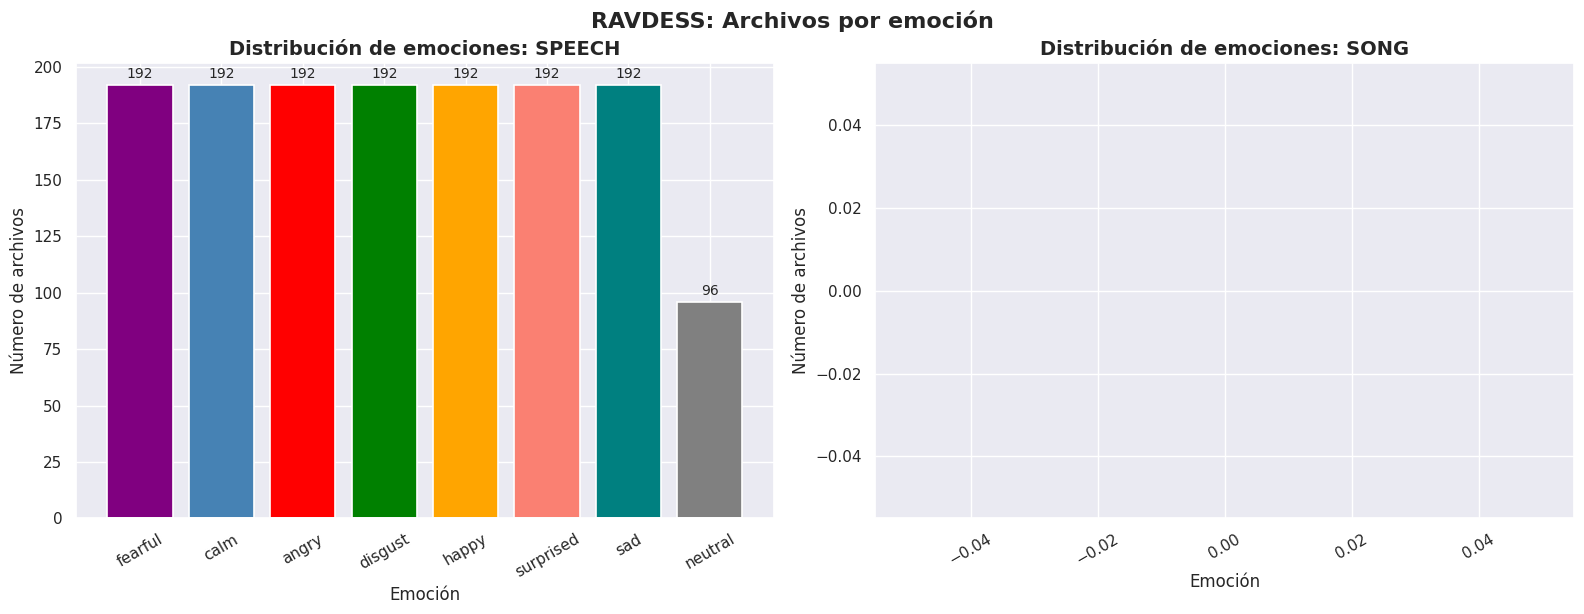

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, channel in zip(axes, ['speech', 'song']):
    subset = df[df['channel'] == channel]
    counts = subset['emotion'].value_counts()
    colors = [EMOTION_COLORS.get(e, '#ccc') for e in counts.index]
    bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.2)
    ax.bar_label(bars, padding=3, fontsize=10)
    ax.set_title(f'Distribución de emociones: {channel.upper()}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Emoción')
    ax.set_ylabel('Número de archivos')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.suptitle('RAVDESS: Archivos por emoción', y=1.02, fontsize=16, fontweight='bold')
plt.show()

## **5. Distribución por género e intensidad**

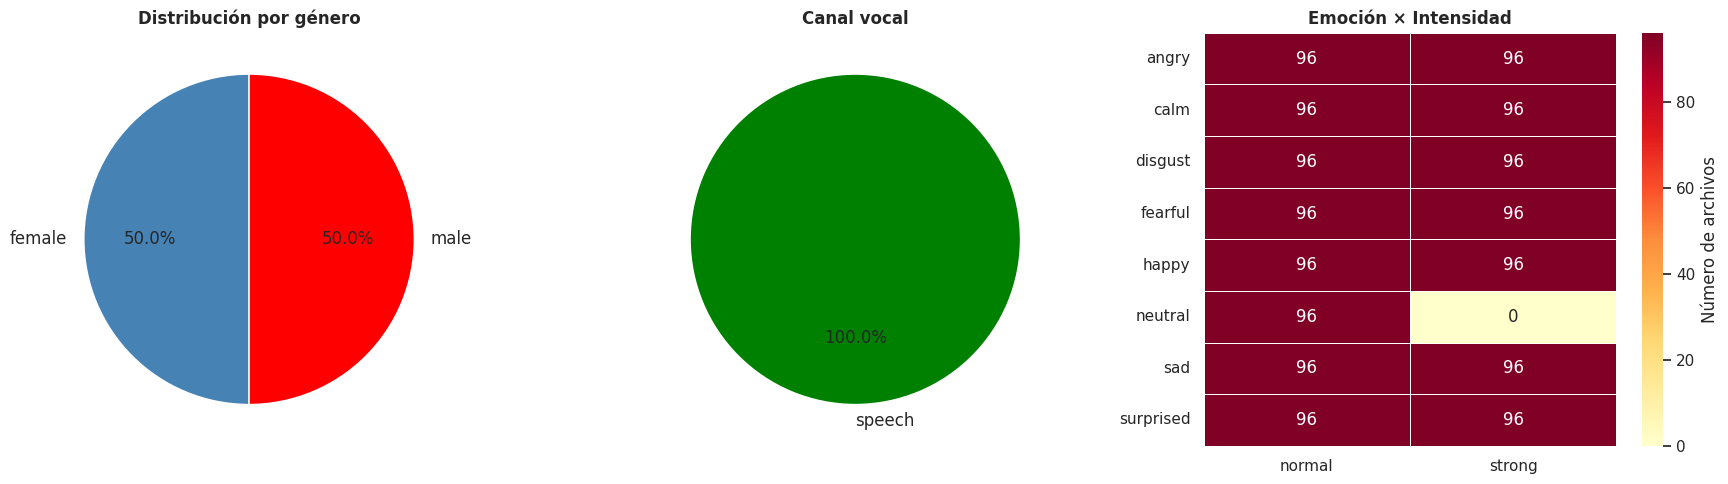

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Género
gender_counts = df['gender'].value_counts()
axes[0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
            colors=['steelblue', 'red'], startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Distribución por género', fontweight='bold')

# Canal (speech vs. song)
channel_counts = df['channel'].value_counts()
axes[1].pie(channel_counts, labels=channel_counts.index, autopct='%1.1f%%',
            colors=['green', 'coral'], startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Canal vocal', fontweight='bold')

# Intensidad por emoción (heatmap)
pivot = df.groupby(['emotion', 'intensity']).size().unstack(fill_value=0)
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', ax=axes[2],
            linewidths=0.5, cbar_kws={'label': 'Número de archivos'})
axes[2].set_title('Emoción × Intensidad', fontweight='bold')
axes[2].set_xlabel('')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

## **6. Emociones por género**


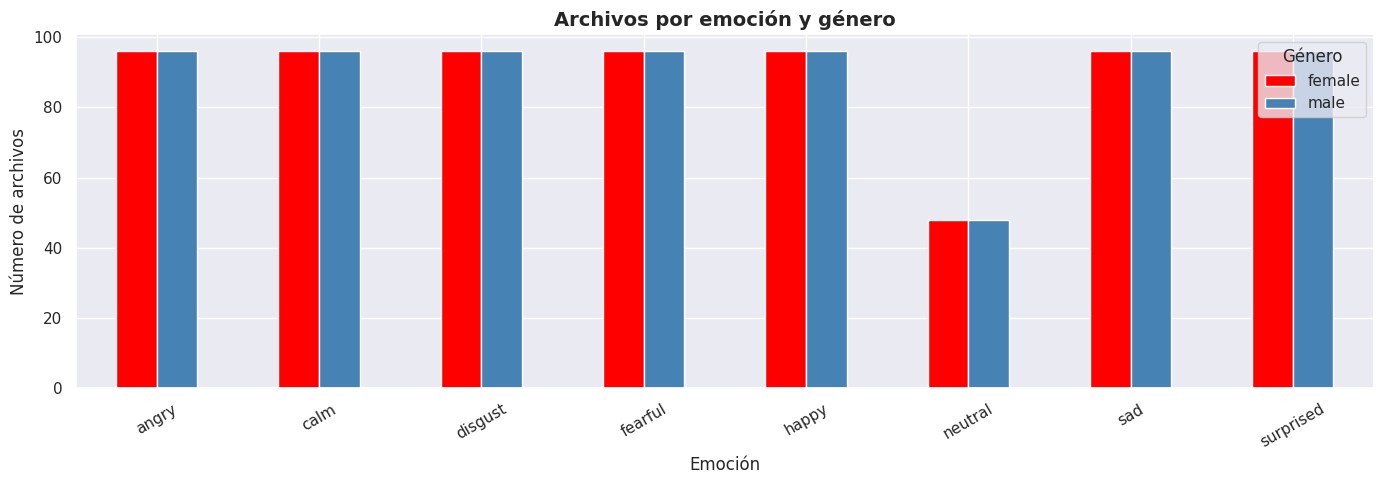

In [25]:
pivot_gender = df.groupby(['emotion', 'gender']).size().unstack(fill_value=0)
pivot_gender.plot(
    kind='bar', figsize=(14, 5), color=['red', 'steelblue'], edgecolor='white', linewidth=1
)
plt.title('Archivos por emoción y género', fontsize=14, fontweight='bold')
plt.xlabel('Emoción')
plt.ylabel('Número de archivos')
plt.xticks(rotation=30)
plt.legend(title='Género')
plt.tight_layout()
plt.show()

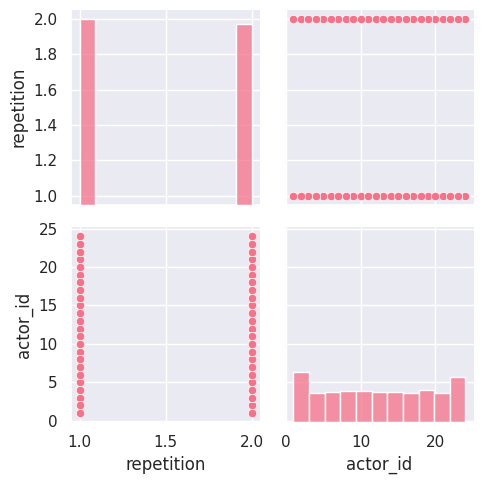

In [26]:
sns.pairplot(data=df.sample(1000))
plt.tight_layout()
plt.show()

## **7. Análisis de audio: extracción de características**

- A continuación, cargamos una muestra de archivos y extraemos características acústicas clave: **duración**, **MFCC**, **chroma**, **espectrograma mel** y **ZCR**.

In [27]:
def extract_features(filepath, sr=22050):
    """Extrae características acústicas básicas de un archivo de audio."""
    try:
        y, sr = librosa.load(filepath, sr=sr)
        duration = librosa.get_duration(y=y, sr=sr)
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        zcr = librosa.feature.zero_crossing_rate(y)
        rms = librosa.feature.rms(y=y)
        return {
            'duration': duration,
            'mfcc_mean': mfccs.mean(axis=1).tolist(),
            'mfcc_std': mfccs.std(axis=1).tolist(),
            'chroma_mean': chroma.mean(),
            'zcr_mean': zcr.mean(),
            'rms_mean': rms.mean(),
        }
    except Exception as e:
        return None

# Muestra estratificada: 5 archivos por emoción (speech únicamente)
speech_df = df[df['channel'] == 'speech'].copy()
sample_df = speech_df.groupby('emotion', group_keys=False).apply(
    lambda g: g.sample(min(5, len(g)), random_state=42)
).reset_index(drop=True)

print(f'Extrayendo características de {len(sample_df)} archivos...')
features_list = []
for _, row in sample_df.iterrows():
    feat = extract_features(row['filepath'])
    if feat:
        feat.update({'emotion': row['emotion'], 'gender': row['gender'],
                     'intensity': row['intensity']})
        features_list.append(feat)

feat_df = pd.DataFrame(features_list)
print(f'Características extraídas de {len(feat_df)} archivos')
feat_df[['emotion', 'gender', 'duration', 'zcr_mean', 'rms_mean', 'chroma_mean']].head(10)

Extrayendo características de 40 archivos...
Características extraídas de 40 archivos


,emotion,gender,duration,zcr_mean,rms_mean,chroma_mean
0,angry,male,4.137506,0.289976,0.027826,0.482446
1,angry,male,3.470159,0.193923,0.011732,0.523300
2,angry,male,4.371066,0.244474,0.032846,0.377900
3,angry,male,3.536916,0.189310,0.023020,0.499852
4,angry,male,3.670340,0.214804,0.051635,0.523666
5,calm,male,4.004036,0.299460,0.004419,0.517888
6,calm,male,3.670340,0.157650,0.001354,0.491539
7,calm,male,3.536871,0.357010,0.001653,0.561585
8,calm,male,3.837188,0.163436,0.001475,0.511059
9,calm,male,2.936281,0.306471,0.001591,0.601372


## **8. Distribución de duraciones por emoción**

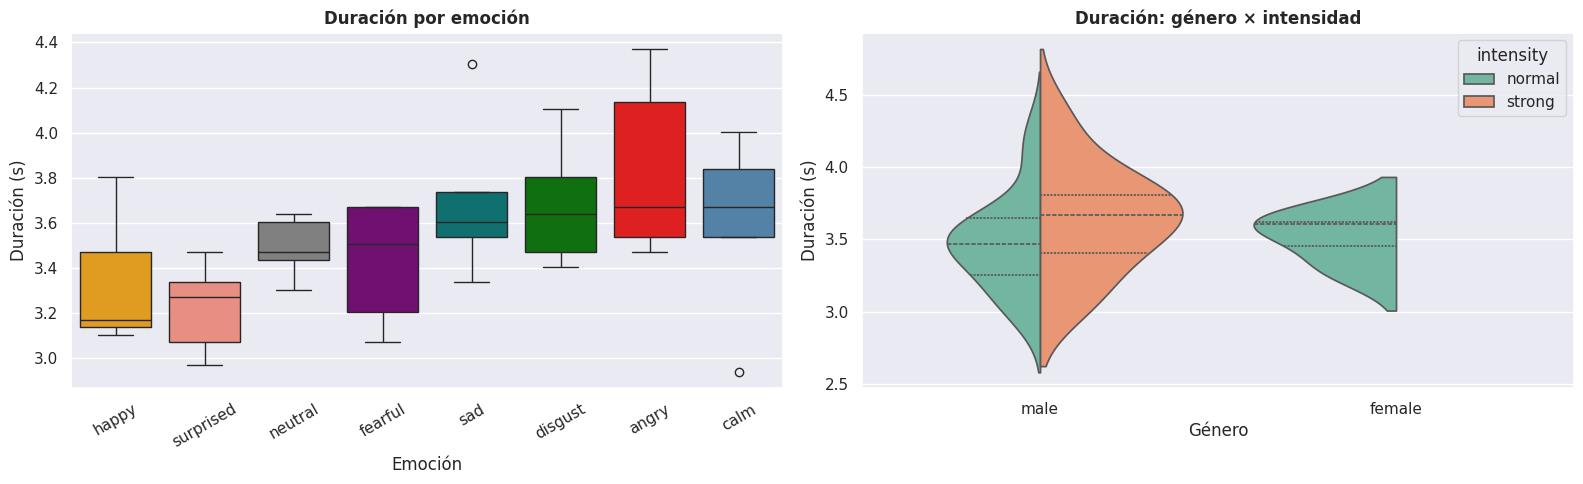

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Boxplot - duración por emoción
emotion_order = feat_df.groupby('emotion')['duration'].median().sort_values().index
sns.boxplot(
    data=feat_df, x='emotion', y='duration', order=emotion_order,
    palette=EMOTION_COLORS, ax=axes[0]
)
axes[0].set_title('Duración por emoción', fontweight='bold')
axes[0].set_xlabel('Emoción')
axes[0].set_ylabel('Duración (s)')
axes[0].tick_params(axis='x', rotation=30)

# Violin plot - duración por género
sns.violinplot(
    data=feat_df, x='gender', y='duration', hue='intensity',
    split=True, inner='quart', palette='Set2', ax=axes[1]
)
axes[1].set_title('Duración: género × intensidad', fontweight='bold')
axes[1].set_xlabel('Género')
axes[1].set_ylabel('Duración (s)')

plt.tight_layout()
plt.show()

In [29]:
# Estadísticas descriptivas
feat_df.groupby('emotion')['duration'].describe().round(3)

,count,mean,std,min,25%,50%,75%,max
emotion,,,,,,,,
angry,5.0,3.837,0.396,3.470,3.537,3.670,4.138,4.371
calm,5.0,3.597,0.409,2.936,3.537,3.670,3.837,4.004
disgust,5.0,3.684,0.282,3.403,3.470,3.637,3.804,4.104
fearful,5.0,3.423,0.275,3.070,3.203,3.504,3.670,3.670
happy,5.0,3.337,0.299,3.103,3.137,3.170,3.470,3.804
neutral,5.0,3.490,0.135,3.303,3.437,3.470,3.604,3.637
sad,5.0,3.704,0.366,3.337,3.537,3.604,3.737,4.304
surprised,5.0,3.223,0.202,2.970,3.070,3.270,3.337,3.470


## **9. Visualización de espectrogramas**

- Comparamos la forma de onda y el espectrograma mel de distintas emociones.

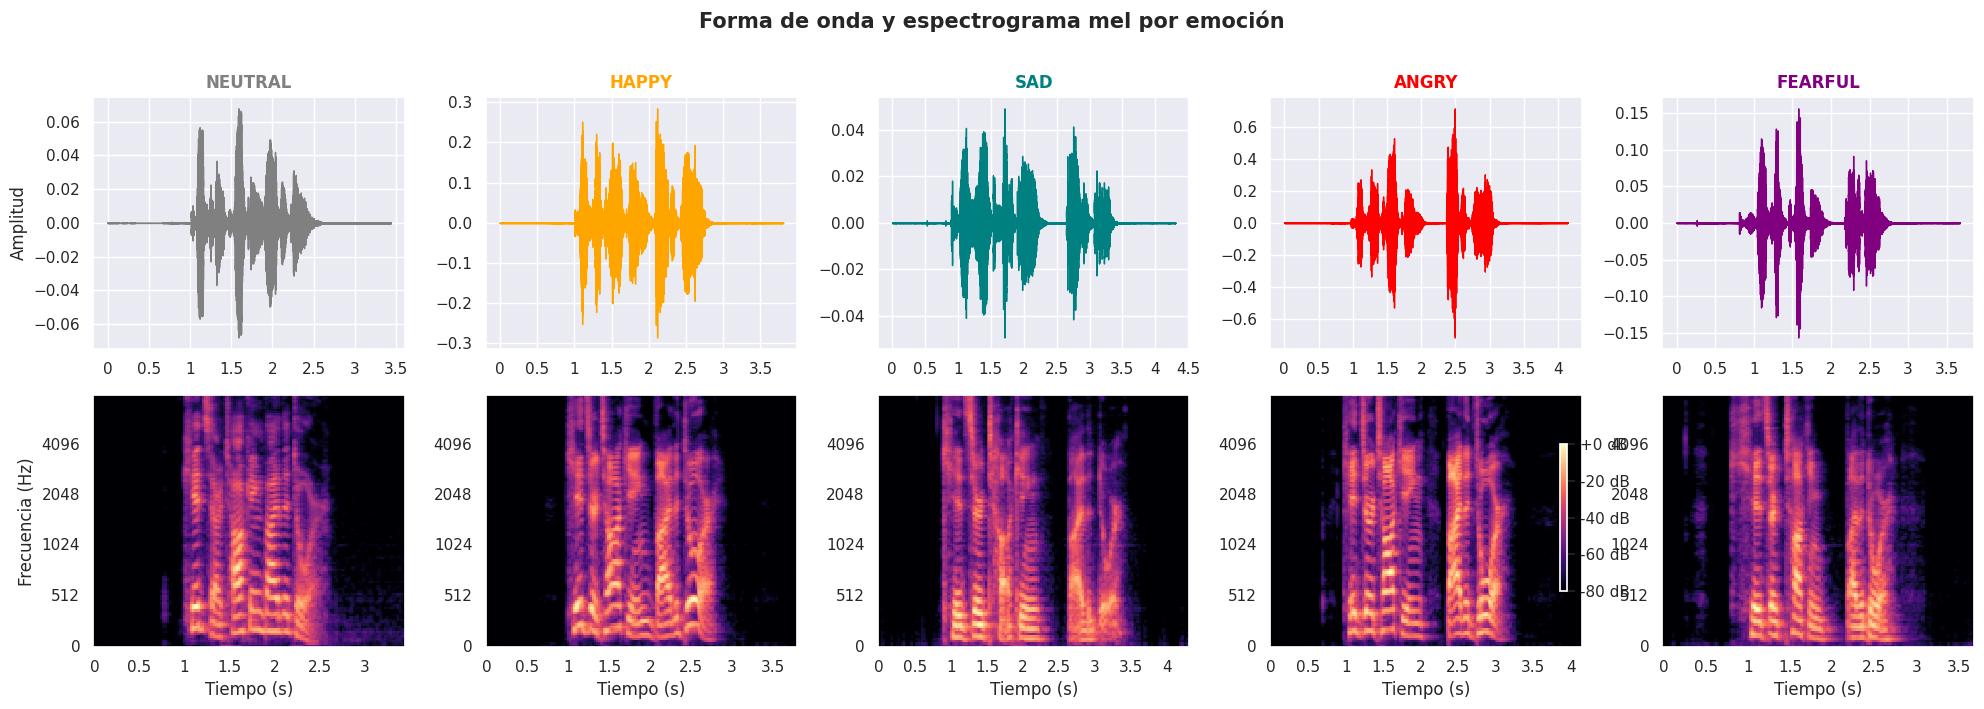

In [30]:
emotions_to_show = ['neutral', 'happy', 'sad', 'angry', 'fearful']

fig, axes = plt.subplots(2, len(emotions_to_show), figsize=(20, 7))

for col, emotion in enumerate(emotions_to_show):
    subset = speech_df[speech_df['emotion'] == emotion]
    if len(subset) == 0:
        continue
    filepath = subset.sample(1, random_state=42).iloc[0]['filepath']
    y, sr = librosa.load(filepath, sr=22050)

    # Forma de onda
    librosa.display.waveshow(y, sr=sr, ax=axes[0, col],
                              color=EMOTION_COLORS.get(emotion, '#888'))
    axes[0, col].set_title(emotion.upper(), fontweight='bold',
                           color=EMOTION_COLORS.get(emotion, '#888'))
    axes[0, col].set_xlabel('')
    if col > 0:
        axes[0, col].set_ylabel('')

    # Espectrograma mel
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
    S_dB = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel',
                                   fmax=8000, ax=axes[1, col], cmap='magma')
    axes[1, col].set_xlabel('Tiempo (s)')
    if col > 0:
        axes[1, col].set_ylabel('')

fig.colorbar(img, ax=axes[1, :], format='%+2.0f dB', shrink=0.6)
axes[0, 0].set_ylabel('Amplitud')
axes[1, 0].set_ylabel('Frecuencia (Hz)')
plt.suptitle('Forma de onda y espectrograma mel por emoción', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## **10. MFCCs medios por emoción**

- Los MFCCs (Mel-Frequency Cepstral Coefficients) son la característica más usada en speech emotion recognition.

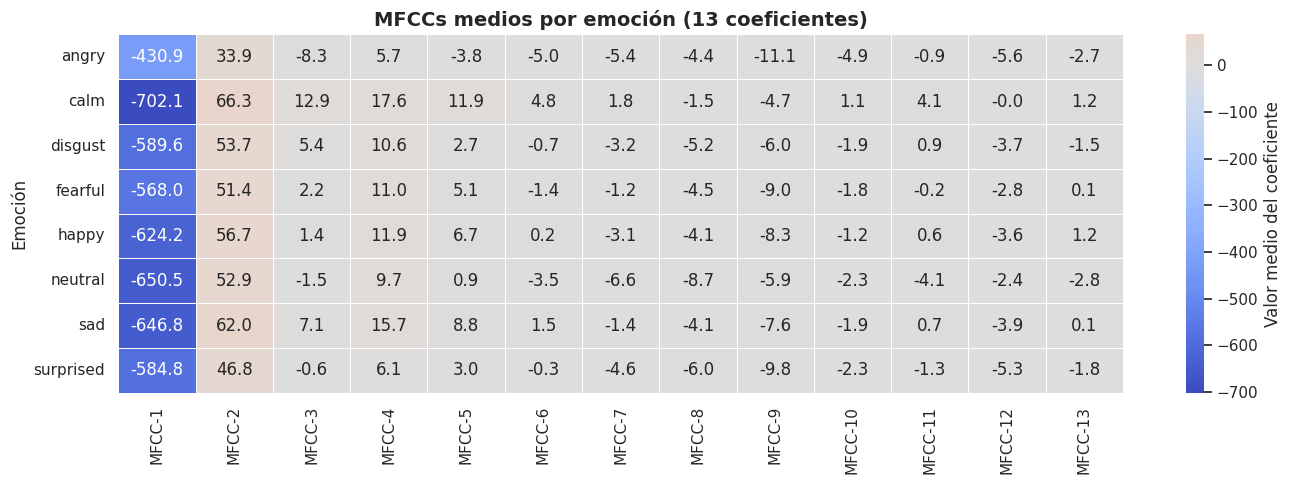

In [31]:
# Extraer MFCCs medios y apilar en matriz
mfcc_by_emotion = {}
for emotion in feat_df['emotion'].unique():
    rows = feat_df[feat_df['emotion'] == emotion]['mfcc_mean'].tolist()
    if rows:
        mfcc_by_emotion[emotion] = np.mean(rows, axis=0)

mfcc_matrix = pd.DataFrame(mfcc_by_emotion).T
mfcc_matrix.columns = [f'MFCC-{i+1}' for i in range(13)]

plt.figure(figsize=(14, 5))
sns.heatmap(
    mfcc_matrix, cmap='coolwarm', center=0,
    annot=True, fmt='.1f', linewidths=0.5,
    cbar_kws={'label': 'Valor medio del coeficiente'}
)
plt.title('MFCCs medios por emoción (13 coeficientes)', fontsize=14, fontweight='bold')
plt.ylabel('Emoción')
plt.tight_layout()
plt.show()

## **11. Características acústicas comparativas**

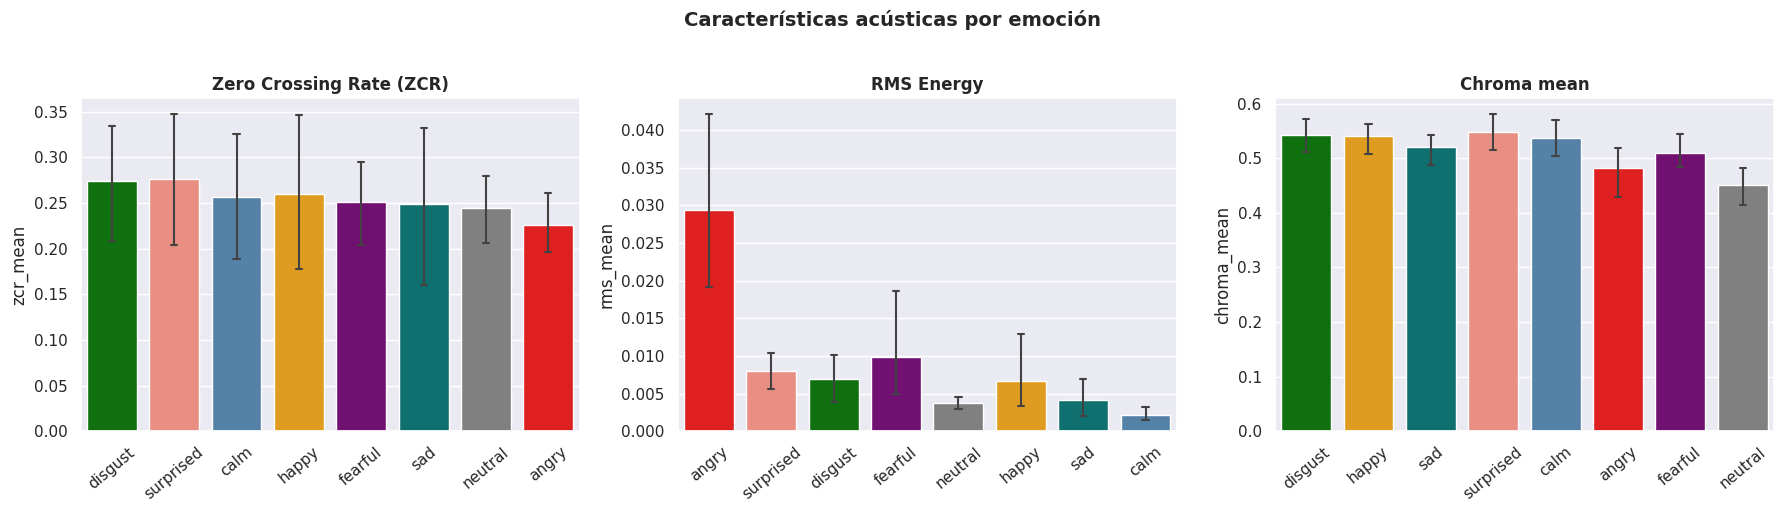

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (col, label) in zip(axes, [
    ('zcr_mean', 'Zero Crossing Rate (ZCR)'),
    ('rms_mean', 'RMS Energy'),
    ('chroma_mean', 'Chroma mean'),
]):
    order = feat_df.groupby('emotion')[col].median().sort_values(ascending=False).index
    sns.barplot(
        data=feat_df, x='emotion', y=col, order=order,
        palette=EMOTION_COLORS, ax=ax, capsize=0.1, errwidth=1.5
    )
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=40)

plt.suptitle('Características acústicas por emoción',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## **12. Mapa de correlación entre características**

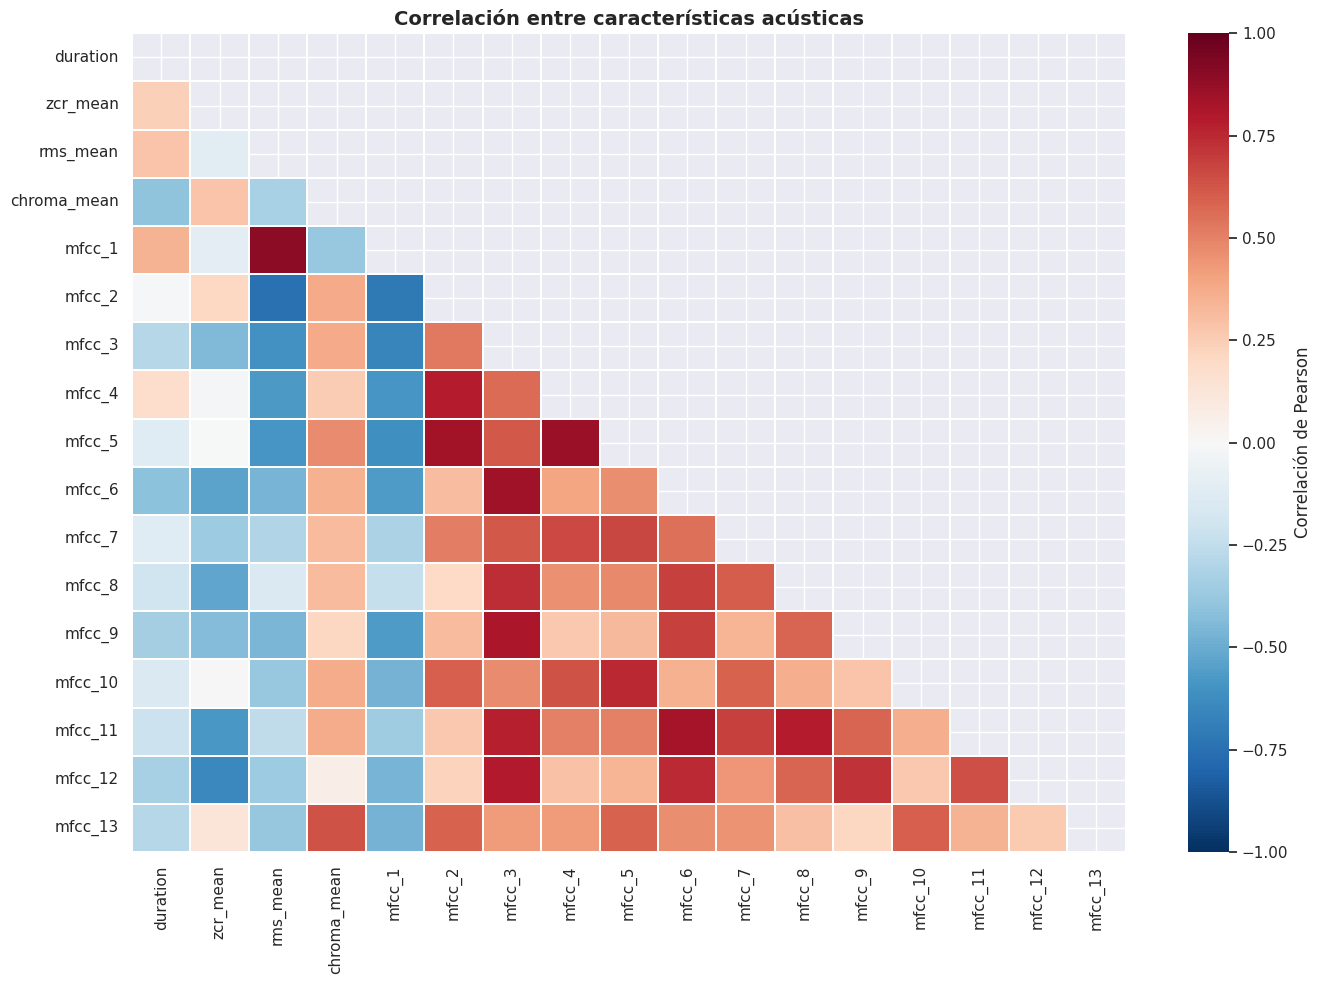

In [33]:
# Expandir MFCC en columnas individuales
mfcc_expanded = pd.DataFrame(
    feat_df['mfcc_mean'].tolist(),
    columns=[f'mfcc_{i+1}' for i in range(13)]
)
feat_numeric = pd.concat([
    feat_df[['duration', 'zcr_mean', 'rms_mean', 'chroma_mean']].reset_index(drop=True),
    mfcc_expanded
], axis=1)

corr = feat_numeric.corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, cmap='RdBu_r', center=0,
    vmin=-1, vmax=1, annot=False, linewidths=0.3,
    cbar_kws={'label': 'Correlación de Pearson'}
)
plt.title('Correlación entre características acústicas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## **13. Reproducir ejemplos de audio**

In [34]:
# Reproduce un ejemplo de cada emoción (solo en Jupyter con audio)
for emotion in sorted(speech_df['emotion'].unique()):
    row = speech_df[speech_df['emotion'] == emotion].sample(1, random_state=1).iloc[0]
    print(f'{emotion.upper():10} — {row["filename"]}')
    display(Audio(row['filepath']))

ANGRY      — 03-01-05-02-01-02-21.wav


CALM       — 03-01-02-01-01-01-21.wav


DISGUST    — 03-01-07-02-01-01-21.wav


FEARFUL    — 03-01-06-01-02-02-21.wav


HAPPY      — 03-01-03-01-01-02-21.wav


NEUTRAL    — 03-01-01-01-01-02-06.wav


SAD        — 03-01-04-01-01-02-21.wav


SURPRISED  — 03-01-08-01-01-01-21.wav


## **14. Resumen estadístico**

In [35]:
print('\nESTADÍSTICAS DE DURACIÓN POR EMOCIÓN (speech):')
print(feat_df.groupby('emotion')['duration'].agg(['count','mean','std','min','max']).round(3).to_string())

print('\n\nENERGÍA (RMS) POR EMOCIÓN:')
print(feat_df.groupby('emotion')['rms_mean'].agg(['mean','std']).round(5).to_string())

print('\n\nZCR POR EMOCIÓN:')
print(feat_df.groupby('emotion')['zcr_mean'].agg(['mean','std']).round(5).to_string())


ESTADÍSTICAS DE DURACIÓN POR EMOCIÓN (speech):
           count   mean    std    min    max
emotion                                     
angry          5  3.837  0.396  3.470  4.371
calm           5  3.597  0.409  2.936  4.004
disgust        5  3.684  0.282  3.403  4.104
fearful        5  3.423  0.275  3.070  3.670
happy          5  3.337  0.299  3.103  3.804
neutral        5  3.490  0.135  3.303  3.637
sad            5  3.704  0.366  3.337  4.304
surprised      5  3.223  0.202  2.970  3.470


ENERGÍA (RMS) POR EMOCIÓN:
              mean      std
emotion                    
angry      0.02941  0.01468
calm       0.00210  0.00130
disgust    0.00692  0.00401
fearful    0.00984  0.00966
happy      0.00671  0.00683
neutral    0.00373  0.00099
sad        0.00417  0.00312
surprised  0.00794  0.00326


ZCR POR EMOCIÓN:
              mean      std
emotion                    
angry      0.22650  0.04163
calm       0.25681  0.09066
disgust    0.27478  0.08164
fearful    0.25112  0.05918
happy 

## **15. Conclusiones**

### **Estructura del dataset**
- Hay **7356 archivos** en total (audio + video). La parte de audio contiene **2452 archivos .wav**.
- Balance perfecto de género: **12 actores masculinos y 12 femeninos**.
- **Speech** cubre 8 emociones; **song** cubre solo 5 (sin disgust ni surprised).
- La emoción `neutral` no tiene variante de intensidad `strong` (solo `normal`).

### **Patrones acústicos observados**
| Emoción | Características destacadas |
|---------|---------------------------|
| **Angry** | Mayor energía (RMS), ZCR elevada |
| **Happy** | ZCR alta, duración media, chroma activo |
| **Sad** | Energía baja, duración larga, ZCR baja |
| **Fearful** | Alta variabilidad en MFCCs |
| **Neutral** | Energía y ZCR intermedias, baja varianza |
| **Calm** | Energía baja, MFCCs suaves |